In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [101]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig5_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff')

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


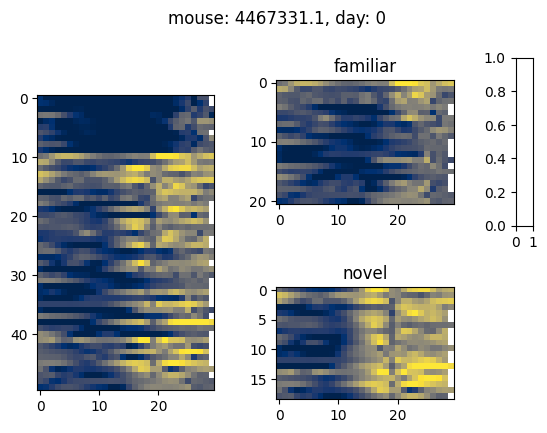

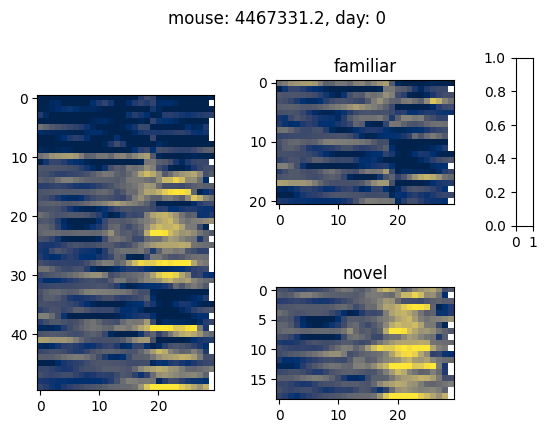

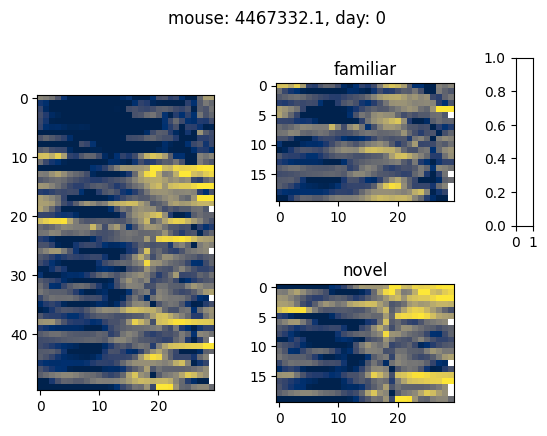

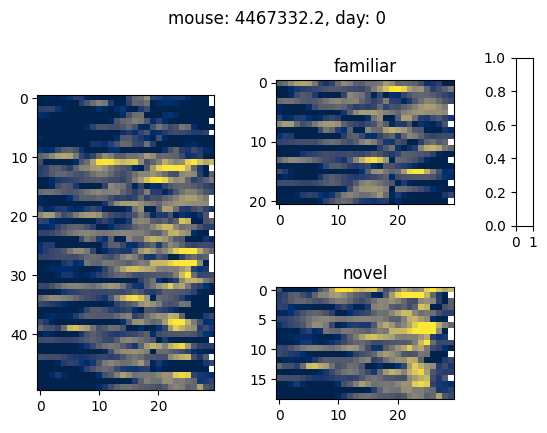

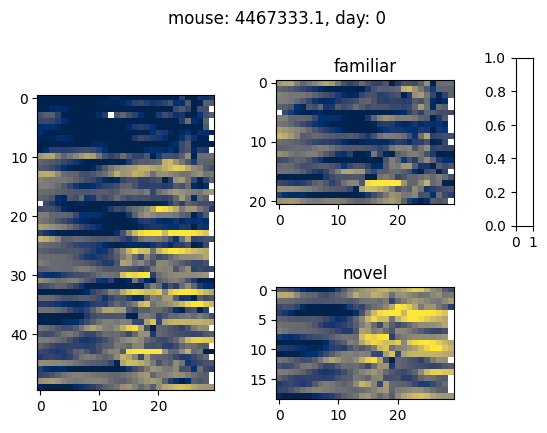

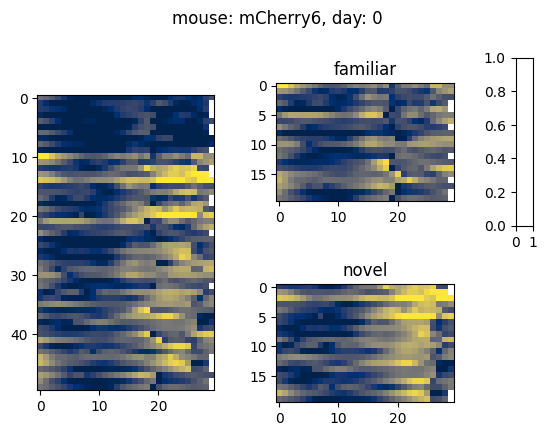

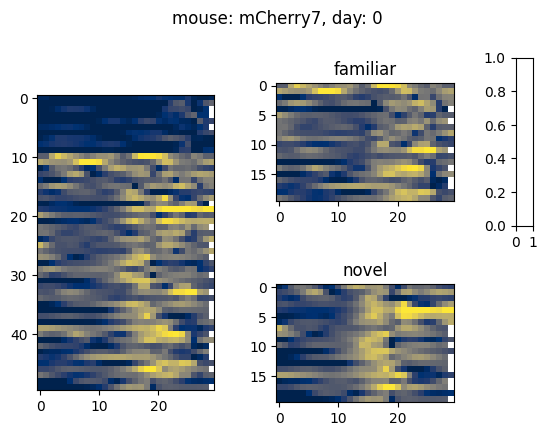

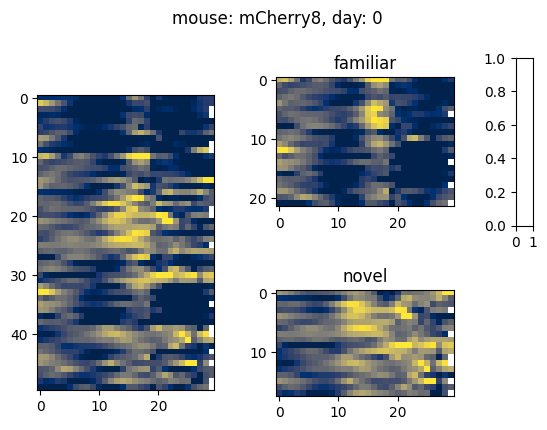

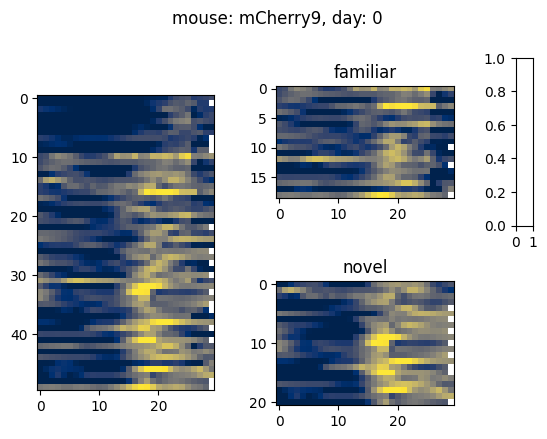

In [149]:
for mouse in ctrl_mice:
    block_rate.plot_single_session('ctrl', mouse, 0, log=False, baseline_corr=True, cmap='cividis', vmin=1)

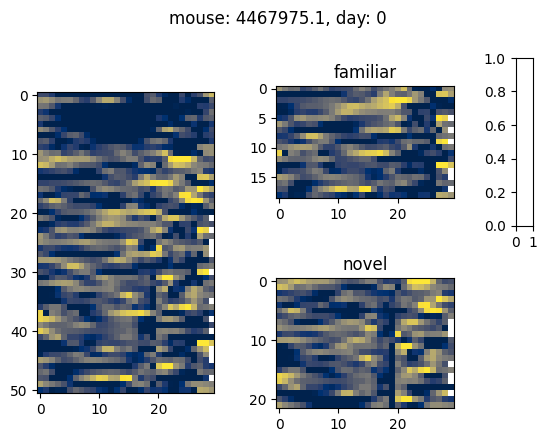

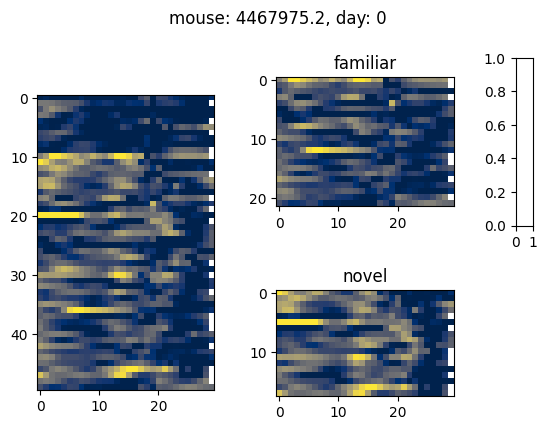

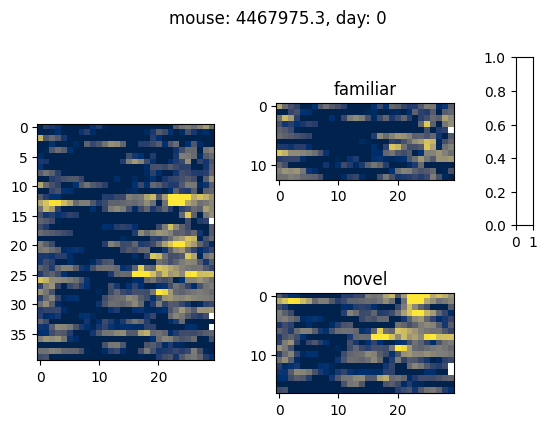

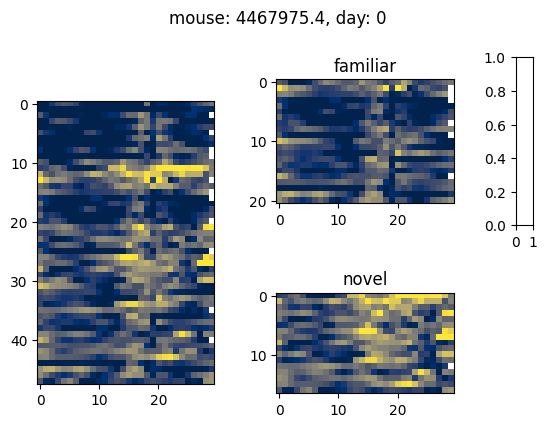

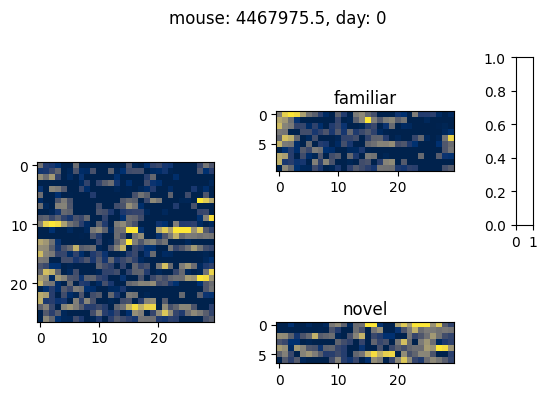

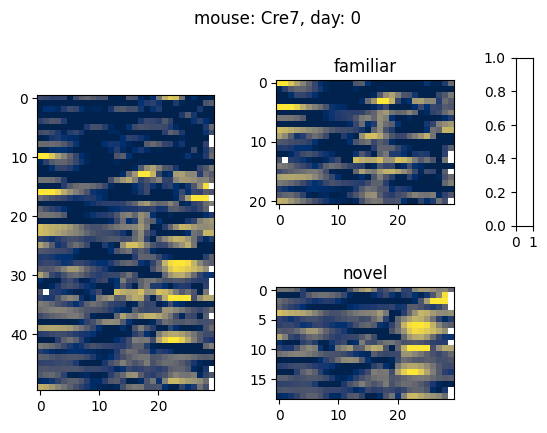

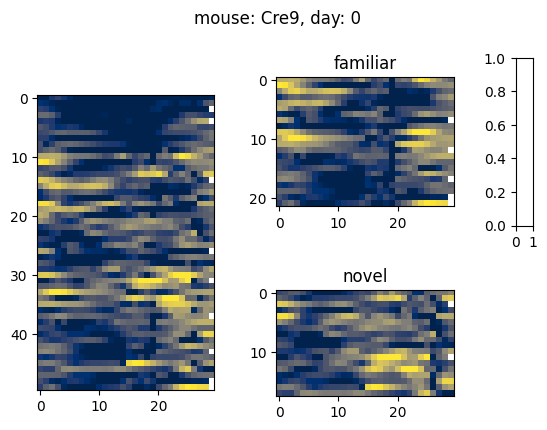

In [150]:
for mouse in ko_mice:
    block_rate.plot_single_session('ko', mouse, 0, log=False, baseline_corr=True, cmap='cividis', vmin=1)

plot average activity, running speed and licks with no normalization

plot population normalized activity, speed and licks

linear model with activity or normalized activity

In [74]:
def plot_block_avg(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
            for i, mouse in enumerate(mice):
                data = block_rate.activity_rates[cond][mouse][day]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base
                    fam[cond][i,:_fam.shape[0]] = _fam
                    nov[cond][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base/_base.mean()
                    fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[cond][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[cond][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[cond][i,:_nov.shape[0]] = _nov

        for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.set_ylabel('dF/F')
        a.set_xlabel('Trial')
    return fig, ax

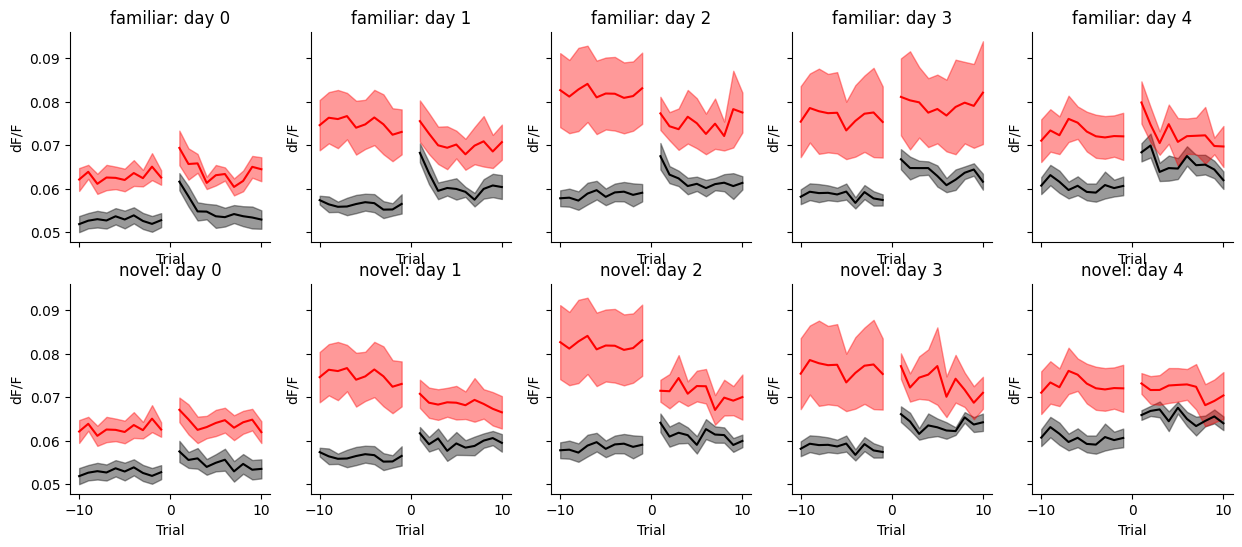

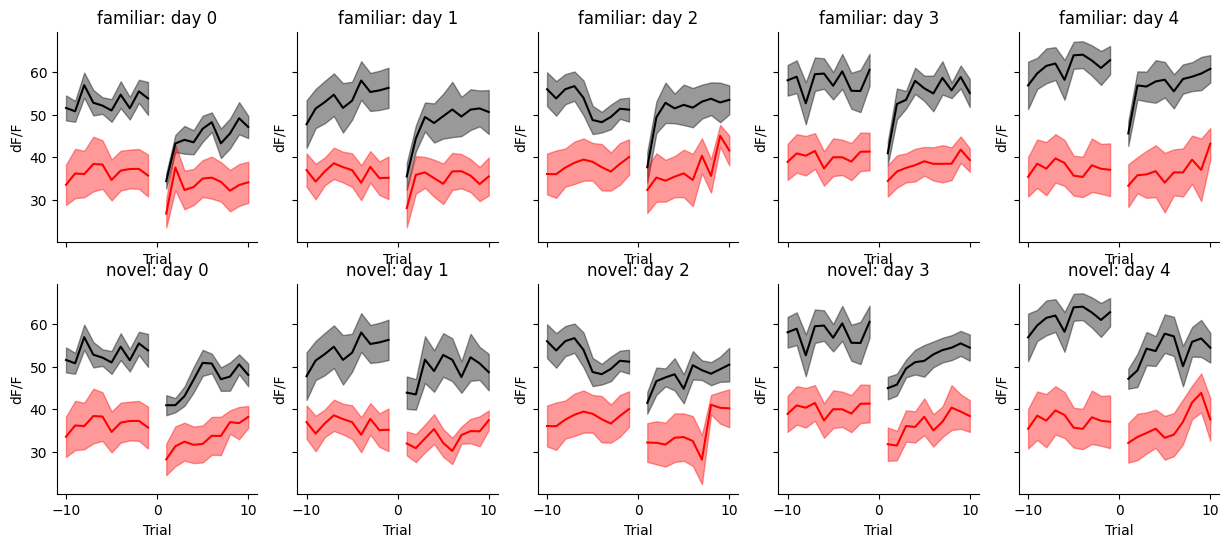

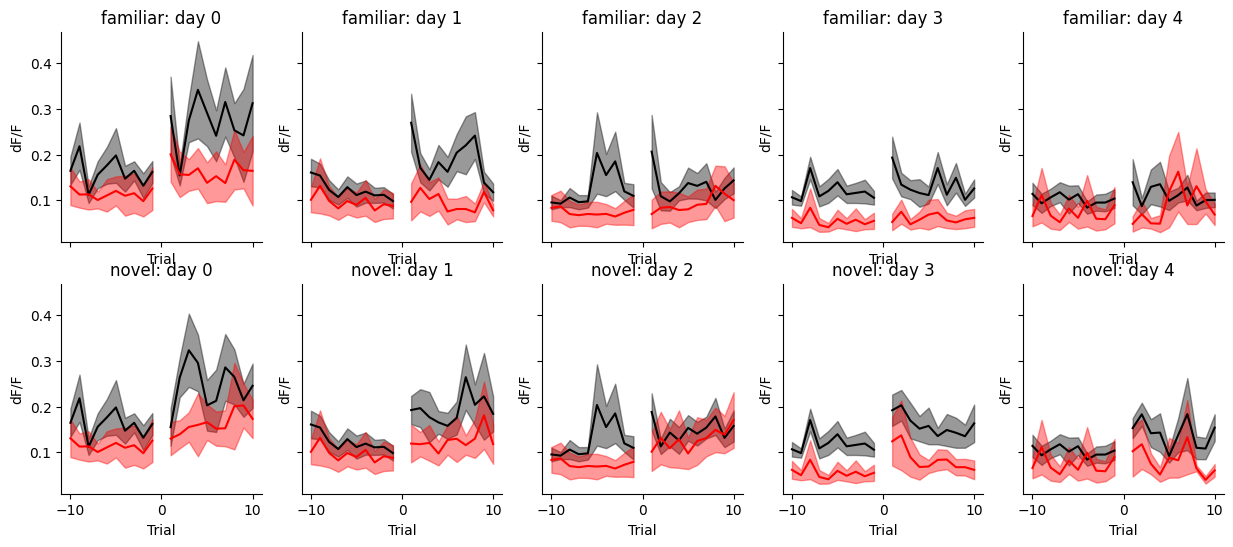

In [77]:
fig, ax = plot_block_avg(block_rate, norm = None, max_trial=10)
fig, ax = plot_block_avg(block_rate, key='speed', norm = None, max_trial=10)
fig, ax = plot_block_avg(block_rate, key='licks', norm = None, max_trial=10)

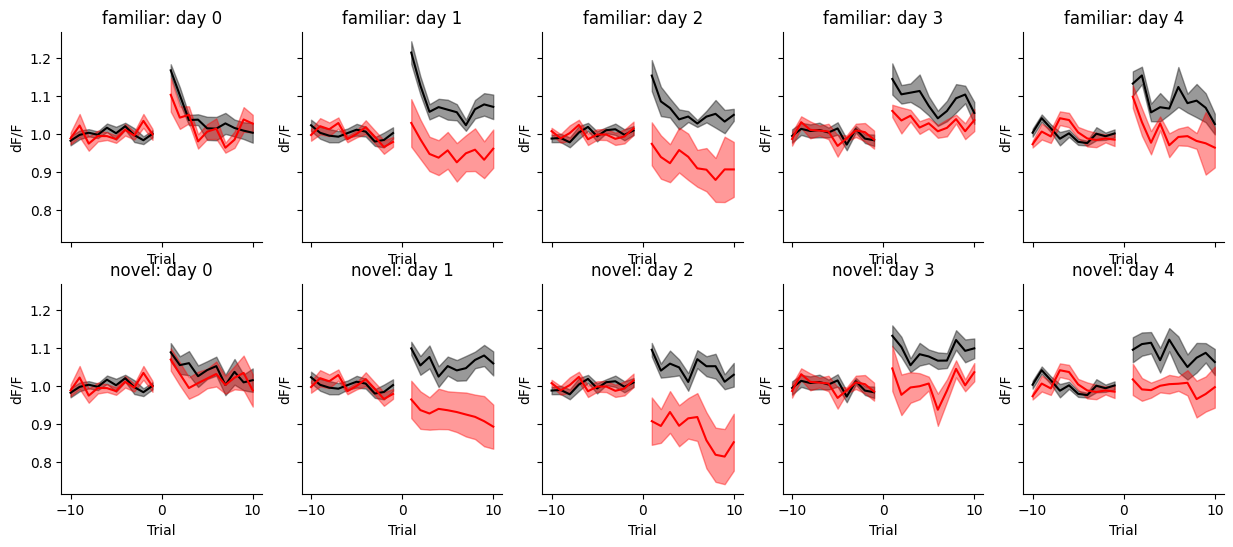

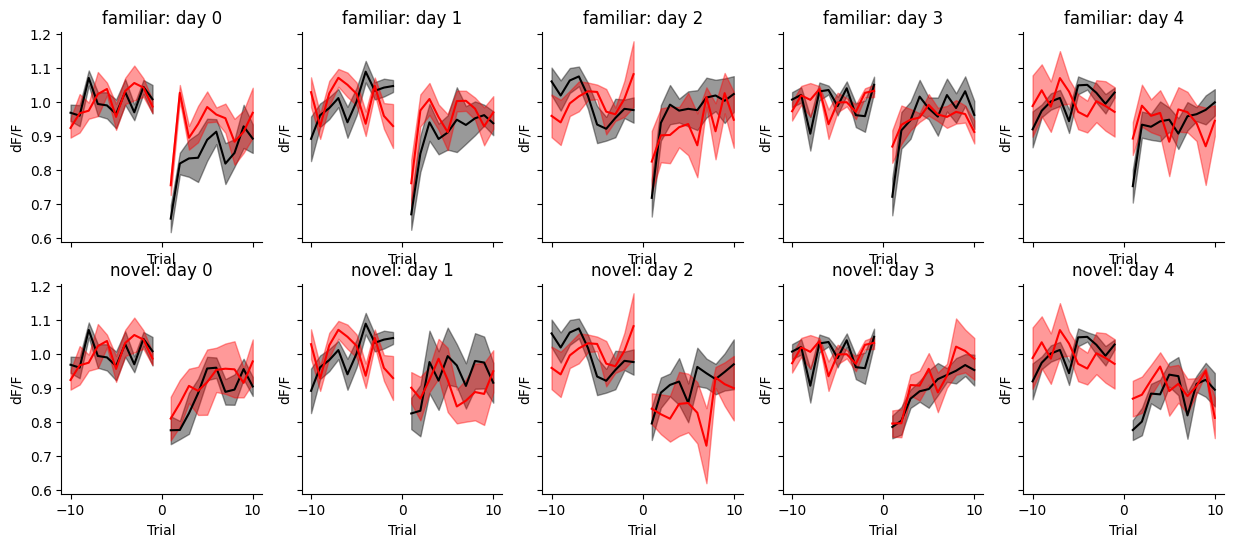

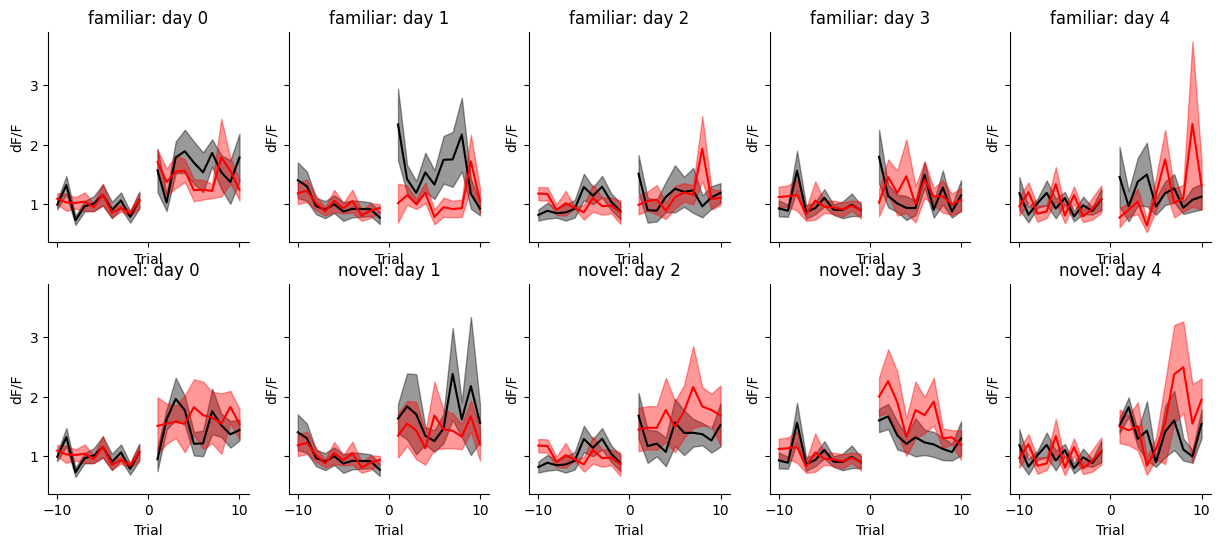

In [76]:
fig, ax = plot_block_avg(block_rate, norm = 'population', max_trial=10)
fig, ax = plot_block_avg(block_rate, key='speed', norm = 'population', max_trial=10)
fig, ax = plot_block_avg(block_rate, key='licks', norm = 'population', max_trial=10)

In [93]:
df = block_rate.build_dataframe(max_trial=5, norm='population', norm_behavior=False)
df = df.loc[df['day']<5]

In [94]:
import statsmodels.formula.api as smf
df['condition'] = df['condition'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')
df['rank_novel_rate'] = df['novel_rate'].rank()

mdl = smf.mixedlm("rank_novel_rate ~ condition + day + novel_speed + novel_licks  ", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_185757/4026433149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['condition'] = df['condition'].astype('category')
/tmp/ipykernel_185757/4026433149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_185757/4026433149.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:            MixedLM Dependent Variable: rank_novel_rate
No. Observations: 80      Method:             REML           
No. Groups:       16      Scale:              261.7871       
Min. group size:  5       Log-Likelihood:     -322.3176      
Max. group size:  5       Converged:          Yes            
Mean group size:  5.0                                        
-------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept        58.685   15.055  3.898 0.000  29.178  88.191
condition[T.ko] -27.791    7.734 -3.594 0.000 -42.949 -12.633
day[T.1]         -8.351    5.953 -1.403 0.161 -20.019   3.318
day[T.2]        -11.044    6.102 -1.810 0.070 -23.003   0.915
day[T.3]          5.369    6.064  0.885 0.376  -6.516  17.253
day[T.4]          0.804    6.354  0.127 0.899 -11.650  13.259
novel_speed       0.014    0.259  0.054 0.957  -0.493   0.521
novel_licks     -26.531   28.748 -0.923 0.356 -82.876  29.814
Group Var       105.557    4.153                             
=============================================================

"""

Shapiro-Wilk: W=0.991, p=0.867
D'Agostino: χ²=0.339, p=0.844


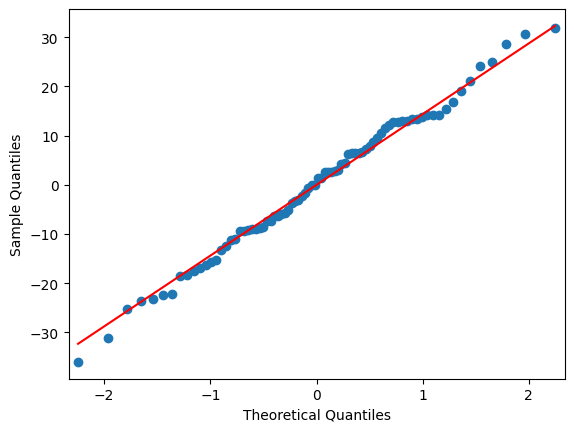

In [96]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson

fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [99]:
df = block_rate.build_dataframe(max_trial=5)

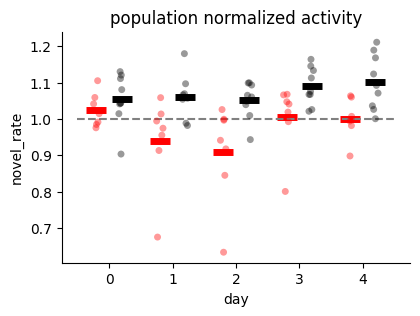

In [102]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=block_rate.df.loc[block_rate.df['day']<5,:],
            x='day',
            y='novel_rate',
            hue='condition', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            dodge=True,
            alpha=.4,
            ax=ax,
            legend=False)



sns.pointplot(data=block_rate.df.loc[block_rate.df['day']<5,:],
            x='day',
            y='novel_rate',
            errorbar=None,
            hue='condition',
            hue_order = ['ko', 'ctrl'],
            dodge = .4,
            palette = ['red','black'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )
ax.set_title('population normalized activity')
ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figdir / 'novel_activity_rate_by_day.pdf', bbox_inches='tight')


In [103]:

res = pg.mixed_anova(data=block_rate.df.loc[block_rate.df['day']<5,:], dv='novel_rate', 
                     within='day', between='condition', subject='mouse')
print(res)

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  0.181406    1   14  0.181406  13.358410  0.002599  0.488274   
1          day  0.057492    4   56  0.014373   3.184916  0.019911  0.185332   
2  Interaction  0.028792    4   56  0.007198   1.595021  0.188360  0.102278   

        eps  
0       NaN  
1  0.605243  
2       NaN  


In [151]:
block_rate_sparse = stx.novel_activity_rate.BlockTransitionActivityRate_Sparse(ts_key='F_dff')

SparseKO_02
SparseKO_06
SparseKO_08


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)


SparseKO_10


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)


SparseKO_11
SparseKO_13


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:287: RuntimeWarning: Mean of empty slice
  axis=0, keepdims=True), axis=1, keepdims=True)


SparseKO_09


In [152]:
def plot_block_avg_sparse(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
        fam = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}
        nov = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}

        for i, mouse in enumerate(sparse_mice):
            for chan in ('channel_0', 'channel_1'):
                if mouse == 'SparseKO_09' and day ==2:
                        continue
                
                data = block_rate_sparse.activity_rates[mouse][day][chan]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base
                    fam[chan][i,:_fam.shape[0]] = _fam
                    nov[chan][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base/_base.mean()
                    fam[chan][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[chan][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[chan][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[chan][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[chan][i,:_nov.shape[0]] = _nov

               

        for chan, color in zip(('channel_1','channel_0'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[chan], axis=0), sp.stats.sem(base[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[chan], axis=0), sp.stats.sem(fam[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[chan], axis=0), sp.stats.sem(nov[chan],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.set_ylabel('dF/F')
        a.set_xlabel('Trial')
    return fig, ax

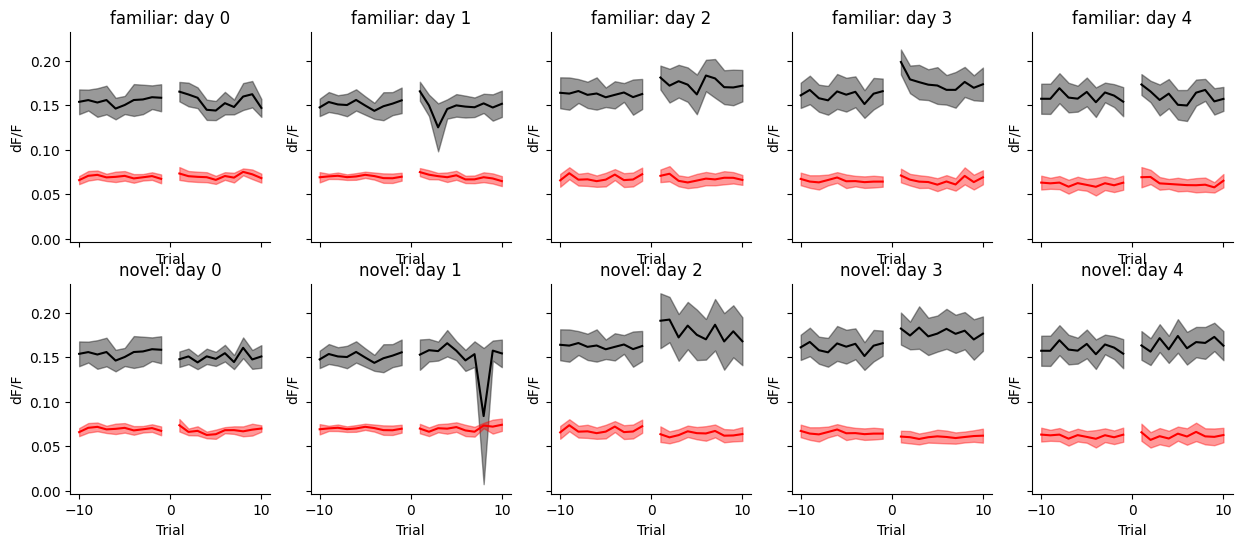

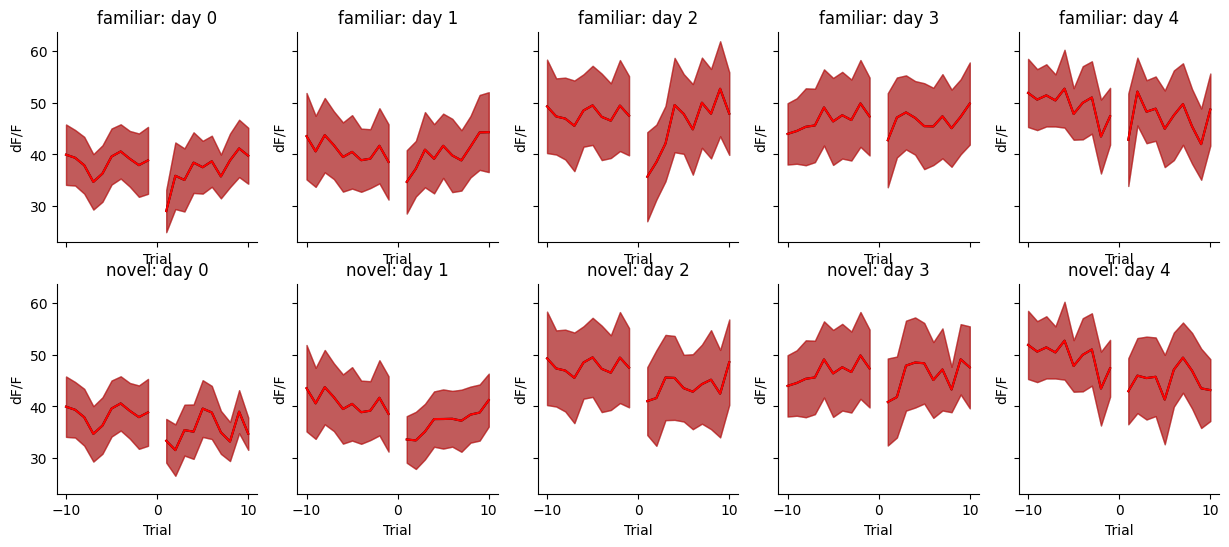

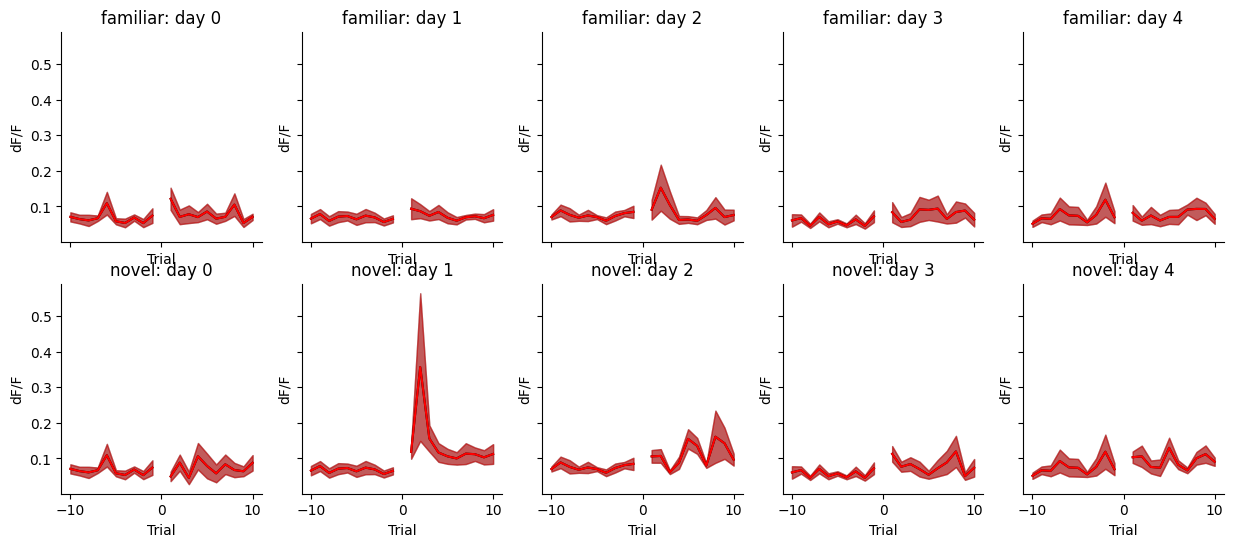

In [153]:
fig, ax = plot_block_avg_sparse(block_rate_sparse, norm = None, max_trial=10)
fig, ax = plot_block_avg_sparse(block_rate_sparse, key='speed', norm = None, max_trial=10)
fig, ax = plot_block_avg_sparse(block_rate_sparse, key='licks', norm = None, max_trial=10)

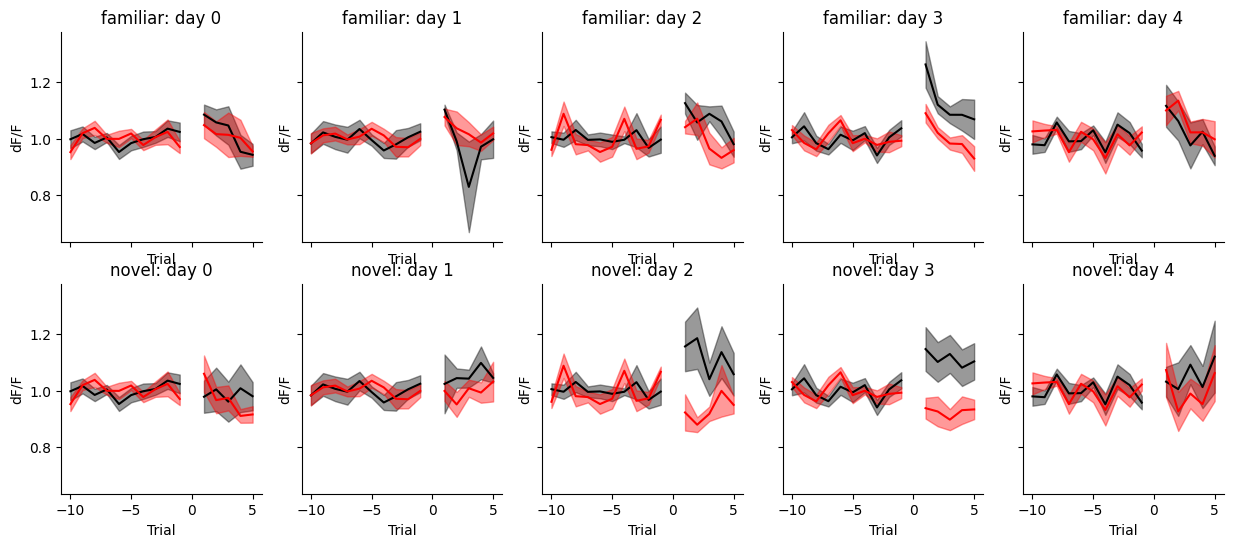

In [154]:
fig, ax = plot_block_avg_sparse(block_rate_sparse, norm ='population', max_trial=5)

In [155]:
df = block_rate_sparse.build_dataframe(max_trial=5)
df = df.loc[df['day']<5]

In [156]:
df['channel'] = df['channel'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')
df['ttype'] = df['ttype'].astype('category')
df['rank_rate'] = df['rate'].rank()

mdl = smf.mixedlm("rank_rate ~ channel*ttype + day + speed + licks ", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_185757/4087403852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['channel'] = df['channel'].astype('category')
/tmp/ipykernel_185757/4087403852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_185757/4087403852.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                      MixedLM         Dependent Variable:         rank_rate
No. Observations:           136             Method:                     REML     
No. Groups:                 7               Scale:                      1352.3403
Min. group size:            16              Log-Likelihood:             -650.8053
Max. group size:            20              Converged:                  Yes      
Mean group size:            19.4                                                 
---------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                            -8.170   30.775 -0.265 0.791 -68.487  52.147
channel[T.channel_1]                  8.265    8.919  0.927 0.354  -9.216  25.746
ttype[T.novel]                      -21.787    9.055 -2.406 0.016 -39.535  -4.040
day[T.1]                              4.449   10.449  0.426 0.670 -16.031  24.929
day[T.2]                             12.033   10.385  1.159 0.247  -8.322  32.387
day[T.3]                             10.011   10.146  0.987 0.324  -9.876  29.897
day[T.4]                             11.946    9.865  1.211 0.226  -7.388  31.281
channel[T.channel_1]:ttype[T.novel]  18.059   12.613  1.432 0.152  -6.663  42.781
speed                                64.920   28.244  2.299 0.022   9.562 120.278
licks                                 7.847    5.330  1.472 0.141  -2.600  18.294
Group Var                            98.946    2.754                             
=================================================================================

"""

Shapiro-Wilk: W=0.972, p=0.0069
D'Agostino: χ²=19.204, p=6.76e-05


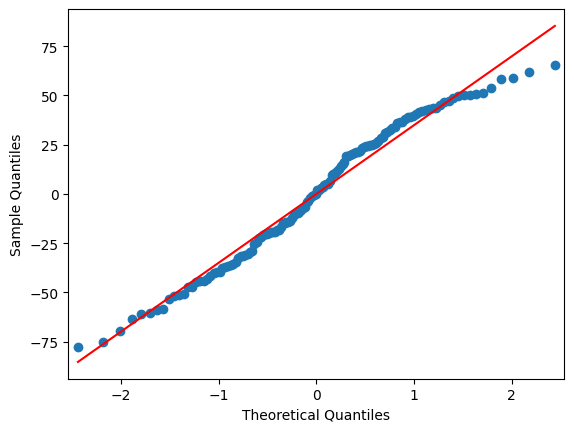

In [157]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

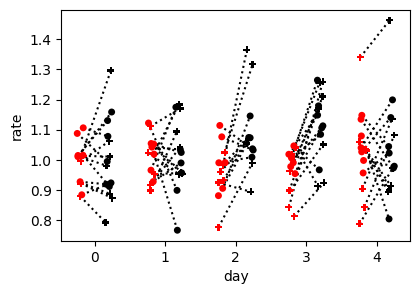

In [158]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype']=='familiar'),:]
sns.stripplot(data=df,
            x='day',
            y='rate',
            hue='channel', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)

df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype']=='novel'),:]

sns.stripplot(data=df,
            x='day',
            y='rate',
            hue='channel', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            marker='P',
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,20,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


In [ ]:
res = pg.rm_anova(data=block_rate_sparse.df.loc[block_rate_sparse.df['day']<5,:],
                  dv='rate', 
                  within=['day', 'channel'],subject='mouse')
print(res)

ValueError: Repeated measures ANOVA with three or more factors is not supported.

In [161]:
df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype'].isin(('novel','familiar'))),:]
df['channel'] = df['channel'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')
df['ttype'] = df['ttype'].astype('category')
df['rank_rate'] = df['rate'].rank()

mdl = smf.mixedlm("rank_rate ~ channel + ttype + day  ", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_185757/1840399932.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['channel'] = df['channel'].astype('category')
/tmp/ipykernel_185757/1840399932.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_185757/1840399932.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:                MixedLM    Dependent Variable:    rank_rate
No. Observations:     136        Method:                REML     
No. Groups:           7          Scale:                 1414.7571
Min. group size:      16         Log-Likelihood:        -664.7204
Max. group size:      20         Converged:             Yes      
Mean group size:      19.4                                       
-----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------
Intercept             55.897    9.002  6.209 0.000  38.253 73.541
channel[T.channel_1]  17.294    6.451  2.681 0.007   4.651 29.937
ttype[T.novel]       -12.088    6.451 -1.874 0.061 -24.731  0.555
day[T.1]              10.321   10.053  1.027 0.305  -9.381 30.024
day[T.2]              11.583   10.511  1.102 0.270  -9.017 32.183
day[T.3]              15.714   10.053  1.563 0.118  -3.988 35.417
day[T.4]              12.964   10.053  1.290 0.197  -6.738 32.667
Group Var             67.966    2.190                            
=================================================================

"""

Shapiro-Wilk: W=0.983, p=0.0931
D'Agostino: χ²=5.853, p=0.0536


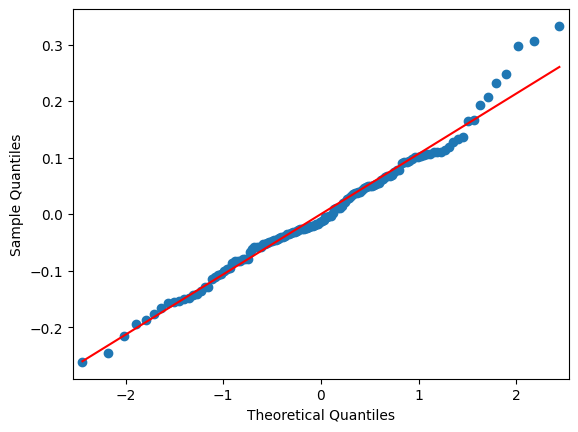

In [148]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")